# Assignment 2: Inference Engineering

**Large Language Models : A Hands on Approach**

Last Updated : 11th April, 2026

**Submission Date** : 26th April 2026



**Late submission pentalty:**

*Before 26 April* - 0%

*Before 3 May* - 25%

*Before 10 May* - 50%

*After 10 May* - 100%


## Overview

This assignment builds your intuition for **why** inference optimizations work

## Structure

| Part | Topic |
|------|-------|
| 1 | Roofline & Arithmetic Intensity
| 2 | KV Cache Memory Budgeting
| 3 | Verify Your Predictions
| 4 | Benchmark Progressions
| 5 | Further Optimizations

## Model

- **Main model:** `Qwen/Qwen3-4B-Instruct-2507` (3.1B parameters)
- **Draft model:** `Qwen/Qwen3-0.6B` (used in later parts)

## Grading

| Part | Weight | Criteria |
|------|--------|----------|
| 1 | 20% | KV cache formula + memory budget analysis |
| 2 | 25% | Quality of comparison between predictions and measurements |
| 3 | 25% | Benchmark results + quality of annotations explaining each transition |
| 4 | 30% | Benchmark results + quality of annotations explaining each transition |


## Submission

**Add all you annotations and code in this notebook. NO EXTRA REPORT NEEDED**

Send this notebook to email id **llmcourse.iisc@gmail.com** and also share this notebook to the same email ID.

NOTE : email ID is different from the last assignment


---
## Setup

In [ ]:
# Install dependencies (run once, restart runtime after)

!pip install  - -upgrade transformers accelerate bitsandbytes
!pip install  vllm


Usage:   
  pip3 install [options] <requirement specifier> [package-index-options] ...
  pip3 install [options] -r <requirements file> [package-index-options] ...
  pip3 install [options] [-e] <vcs project url> ...
  pip3 install [options] [-e] <local project path> ...
  pip3 install [options] <archive url/path> ...

no such option: ---upgrade
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 4.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.9/87.9 kB 10.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 432.3/432.3 MB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 196.5/196.5 kB 22.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.5/45.5 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 267.7/267.7 MB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 161.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 111.0/111.0 kB 14.2 MB/s eta 0:00:00
   ━━━━━━━━━━━

In [ ]:
import torch
import time
import gc
import numpy as np
from dataclasses import dataclass, field
from typing import Optional, List

# Suppress warnings
import warnings
warnings.filterwarnings('ignore')

In [ ]:
# ---------- GPU Detection ----------
assert torch.cuda.is_available(), "GPU required. Go to Runtime > Change runtime type > T4 GPU"

gpu_name = torch.cuda.get_device_name(0)
gpu_mem_gb = torch.cuda.get_device_properties(0).total_memory / 1024**3
compute_cap = torch.cuda.get_device_capability()

print(f"GPU: {gpu_name}")
print(f"Memory: {gpu_mem_gb:.1f} GB")
print(f"Compute Capability: {compute_cap[0]}.{compute_cap[1]}")

# ---------- T4 Hardware Specs ----------

GPU_SPECS = {
    "T4": {
        "peak_flops_fp16": 65e12,      # 65 TFLOPS FP16 (Tensor Cores)
        "bandwidth_bytes": 320e9,       # 320 GB/s GDDR6
        "memory_gb": 16,               # 16 GB
    },

    "H100": {
        "peak_flops_fp16": 990e12,     # 990 TFLOPS FP16 (Tensor Cores)
        "bandwidth_bytes": 3350e9,      # 3.35 TB/s HBM3
        "memory_gb": 80,
    }
}


SPECS = GPU_SPECS["T4"]
print(f"\nUsing specs: Peak FP16 = {SPECS['peak_flops_fp16']/1e12:.0f} TFLOPS, "
      f"Bandwidth = {SPECS['bandwidth_bytes']/1e9:.0f} GB/s, "
      f"Memory = {SPECS['memory_gb']} GB")

GPU: Tesla T4
Memory: 14.6 GB
Compute Capability: 7.5

Using specs: Peak FP16 = 65 TFLOPS, Bandwidth = 320 GB/s, Memory = 16 GB


In [ ]:
# ---------- Model Specifications ----------

MODEL_NAME = "Qwen/Qwen3-4B-Instruct-2507"
DRAFT_MODEL_NAME = "Qwen/Qwen3-0.6B"

# Qwen3-4B architecture
CFG = {
    "D": 2560,       # hidden_size
    "L": 36,         # num_hidden_layers
    "N": 32,         # num_attention_heads (query heads)
    "K": 8,          # num_key_value_heads
    "H": 128,        # head_dim
    "F": 9728,       # intermediate_size (FFN)
    "V": 151936,     # vocab_size
}

# Derived values
CFG["GQA_ratio"] = CFG["N"] // CFG["K"]
CFG["Q_dim"] = CFG["N"] * CFG["H"]
CFG["KV_dim"] = CFG["K"] * CFG["H"]

# Attention per layer: Q(D*Q_dim) + K(D*KV_dim) + V(D*KV_dim) + O(Q_dim*D)
attn_params_per_layer = CFG["D"]*CFG["Q_dim"] + 2*CFG["D"]*CFG["KV_dim"] + CFG["Q_dim"]*CFG["D"]
# MLP per layer: gate(D*F) + up(D*F) + down(F*D)
mlp_params_per_layer = 3 * CFG["D"] * CFG["F"]
# Embeddings + LM Head (Tied weights: V * D)
embed_params = CFG["V"] * CFG["D"]

total_params = CFG["L"] * (attn_params_per_layer + mlp_params_per_layer) + embed_params
model_size_fp16_gb = total_params * 2 / 1024**3
model_size_int4_gb = total_params * 0.5 / 1024**3

print("Qwen3-4B Architecture:")
for k, v in CFG.items():
    print(f"  {k}: {v}")

print(f"\nEstimated parameters: {total_params/1e9:.2f}B")
print(f"Model size (FP16): {model_size_fp16_gb:.2f} GB")
print(f"Model size (INT4): {model_size_int4_gb:.2f} GB")

Qwen3-4B Architecture:
  D: 2560
  L: 36
  N: 32
  K: 8
  H: 128
  F: 9728
  V: 151936
  GQA_ratio: 4
  Q_dim: 4096
  KV_dim: 1024

Estimated parameters: 4.02B
Model size (FP16): 7.49 GB
Model size (INT4): 1.87 GB


---
# Part 1: Roofline & Arithmetic Intensity


**Key formula:**

$$\text{Arithmetic Intensity (AI)} = \frac{\text{FLOPs}}{\text{Bytes Transferred}}$$

$$\text{Roofline Knee Point} = \frac{\text{Peak FLOPs/s}}{\text{Memory Bandwidth (bytes/s)}}$$

- If AI < knee point -> **memory-bound** (GPU starved for data)
- If AI > knee point -> **compute-bound** (GPU fully utilized)

### Q1.1 : Compute the Roofline Knee Point

**Task:**
1. Compute the knee point for the **T4** GPU
2. Compute the knee point for the **H100** GPU
3. Answer: If you had budget for one GPU upgrade for an LLM inference workload, would you prioritize more FLOPs or more bandwidth? Why?

In [ ]:
# Q1.1 — Compute knee points

# T4 knee point
t4_knee = GPU_SPECS["T4"]["peak_flops_fp16"] / GPU_SPECS["T4"]["bandwidth_bytes"]

# H100 knee point
h100_knee = GPU_SPECS["H100"]["peak_flops_fp16"] / GPU_SPECS["H100"]["bandwidth_bytes"]

print(f"T4  knee point: {t4_knee:.1f} FLOPs/byte")
print(f"H100 knee point: {h100_knee:.1f} FLOPs/byte")
print()
print(f"H100 knee is {h100_knee/t4_knee:.1f}x higher than T4")
print("This means H100 needs higher arithmetic intensity to be compute-bound.")


T4  knee point: 203.1 FLOPs/byte
H100 knee point: 295.5 FLOPs/byte

H100 knee is 1.5x higher than T4
This means H100 needs higher arithmetic intensity to be compute-bound.


**Q1.1 Analysis:** If you had budget for one GPU upgrade for LLM decode serving, would you pick 2x FLOPs or 2x bandwidth? Why?

Answer :

**TODO** : ADD YOUR ANSWER


*...*

### Q1.2 : MLP Arithmetic Intensity

The MLP block in a transformer computes:

$$Y = \text{SiLU}(X \cdot W_{\text{gate}}) \odot (X \cdot W_{\text{up}}) \cdot W_{\text{down}}$$

Where $X$ is shape $[B, T, D]$, and $W_{\text{gate}}, W_{\text{up}}$ are $[D, F]$, $W_{\text{down}}$ is $[F, D]$.

**The key derivation** (from class):

$$\text{FLOPs}_{\text{MLP}} = 6 \cdot B \cdot T \cdot D \cdot F$$

$$\text{Bytes}_{\text{MLP}} = 2 \cdot (2 \cdot B \cdot T \cdot D + 3 \cdot D \cdot F + 2 \cdot B \cdot T \cdot F)$$

(Factor of 2 for FP16 = 2 bytes per element. Reads: input X, three weight matrices. Writes: intermediate activations and output.)

**Task:** Implement the formula and fill the table for Qwen3-4B (D=2560, F=9728).

In [ ]:


def mlp_arithmetic_intensity(B, T, D, F, dtype_bytes=2):
    """
    Compute arithmetic intensity for one SwiGLU MLP block.

    Args:
        B: batch size
        T: token count (sequence length for prefill, 1 for decode)
        D: hidden dimension
        F: intermediate (FFN) dimension
        dtype_bytes: bytes per element (2 for FP16/BF16)
    Returns:
        Arithmetic intensity in FLOPs/byte
    """
    flops = 6 * B * T * D * F
    bytes_transferred = dtype_bytes * (2 * B * T * D + 3 * D * F + 2 * B * T * F)
    return flops / bytes_transferred

# Fill this table for Qwen3-4B
D, F = CFG["D"], CFG["F"]
t4_knee = SPECS["peak_flops_fp16"] / SPECS["bandwidth_bytes"]

scenarios = [
    ("Single decode",    1,  1),
    ("Batched decode",  32,  1),
    ("Short prefill",    1, 128),
    ("Long prefill",     1, 1024),
    ("Batched prefill",  8, 512),
]

print(f"{'Scenario':<20} {'B':>4} {'T':>6} {'AI (FLOPs/byte)':>16} {'Bound on T4':>14}")
print("-" * 65)
for name, B, T in scenarios:
    ai = mlp_arithmetic_intensity(B, T, D, F)
    bound = "COMPUTE" if ai > t4_knee else "MEMORY"
    print(f"{name:<20} {B:>4} {T:>6} {ai:>16.1f} {bound:>14}")

print()
print(f"T4 knee point: {t4_knee:.1f} FLOPs/byte")


Scenario                B      T  AI (FLOPs/byte)    Bound on T4
-----------------------------------------------------------------
Single decode           1      1              1.0         MEMORY
Batched decode         32      1             31.7         MEMORY
Short prefill           1    128            122.8         MEMORY
Long prefill            1   1024            766.0        COMPUTE
Batched prefill         8    512           1744.9        COMPUTE

T4 knee point: 203.1 FLOPs/byte


**Q1.2 Analysis:**

1. What batch size would be needed to make MLP **compute-bound during decode** (T=1) on T4? Is this realistic given T4's 16GB memory?

2. Why does prefill (large T) naturally land in the compute-bound regime while decode (T=1) is stuck in memory-bound?

**TODO** : ADD YOUR ANSWER

*...*

### Q1.3 :  Attention Arithmetic Intensity (and Why Batching Doesn't Help)

For the attention block during **decode** (T=1, attending to KV cache of length S):

With GQA ($N_q$ query heads, $N_{kv}$ KV heads, head dimension $H$):

**FLOPs** (QK^T + softmax@V for all query heads):
$$\text{FLOPs}_{\text{attn}} = 4 \cdot B \cdot S \cdot N_q \cdot H$$

**Bytes** (read Q, K cache, V cache, write output):
$$\text{Bytes}_{\text{attn}} = 2 \cdot (2 \cdot B \cdot N_q \cdot H + 2 \cdot B \cdot S \cdot N_{kv} \cdot H)$$

- Q and output: each $B \times 1 \times N_q \times H$ elements
- K, V cache: each $B \times S \times N_{kv} \times H$ elements

**Task:**
1. Implement `attention_arithmetic_intensity` for decode (T=1)
2. Compute AI at S=512, S=2048, S=8192 for batch sizes B=1, 8, 32
3. Show why **B cancels out** — batching doesn't improve attention AI

In [ ]:


def attention_arithmetic_intensity(B, S, N_q, N_kv, H, dtype_bytes=2):
    """
    Compute arithmetic intensity for attention during decode (T=1).

    Args:
        B: batch size
        S: KV cache sequence length (context seen so far)
        N_q: number of query heads
        N_kv: number of KV heads
        H: head dimension
        dtype_bytes: bytes per element
    Returns:
        Arithmetic intensity in FLOPs/byte
    """
    flops = 4 * B * S * N_q * H
    bytes_transferred = dtype_bytes * (2 * B * N_q * H + 2 * B * S * N_kv * H)
    return flops / bytes_transferred


N_q, N_kv, H = CFG["N"], CFG["K"], CFG["H"]

print(f"{'S':>6} {'B':>4} {'AI':>10} {'Bound':>10}")
print("-" * 35)
for S in [512, 2048, 8192]:
    for B in [1, 8, 32]:
        ai = attention_arithmetic_intensity(B, S, N_q, N_kv, H)
        bound = "COMPUTE" if ai > t4_knee else "MEMORY"
        print(f"{S:>6} {B:>4} {ai:>10.2f} {bound:>10}")
    print()

# Show the limiting AI as S → ∞
ai_limit = N_q / N_kv
print(f"Attention AI limit (S→∞, GQA ratio {N_q}/{N_kv}): {ai_limit:.1f}")
print(f"With full MHA (N_kv=N_q), limit would be: {N_q/N_q:.1f}")


     S    B         AI      Bound
-----------------------------------
   512    1       3.97     MEMORY
   512    8       3.97     MEMORY
   512   32       3.97     MEMORY

  2048    1       3.99     MEMORY
  2048    8       3.99     MEMORY
  2048   32       3.99     MEMORY

  8192    1       4.00     MEMORY
  8192    8       4.00     MEMORY
  8192   32       4.00     MEMORY

Attention AI limit (S→∞, GQA ratio 32/8): 4.0
With full MHA (N_kv=N_q), limit would be: 1.0


**Q1.3 Analysis:**
MLP weights are **shared** across the batch (read once, used B times). KV cache is **per-sequence** (each sequence has its own). Explain in 2-3 sentences why this fundamental difference means batching helps MLP throughput but not attention throughput.

**TODO** : ADD YOUR ANSWER

*...*

### Q1.4 : Napkin Math: Decode Throughput Prediction

The GPU spends most of its time reading model weights from memory.

This gives us a simple throughput formula:

$$\text{Decode throughput (tokens/sec)} \approx \frac{\text{Memory Bandwidth (bytes/sec)}}{\text{Model Size (bytes)}}$$

This can give a upper bound.

**Task:** Predict decode throughput for Qwen3-4B on T4 at batch=1 for:
1. FP16 weights
2. INT4 weights


In [ ]:


bandwidth = SPECS["bandwidth_bytes"]  # 320 GB/s

# FP16: 2 bytes per parameter
model_bytes_fp16 = total_params * 2
throughput_fp16 = bandwidth / model_bytes_fp16

# INT4: ~0.5 bytes per parameter (4 bits + some overhead for scales)
model_bytes_int4 = total_params * 0.5
throughput_int4 = bandwidth / model_bytes_int4

print("=== Napkin Math Predictions (Qwen3-4B on T4, batch=1) ===")
print()
print(f"FP16: {model_bytes_fp16/1e9:.2f} GB model -> {throughput_fp16:.1f} tokens/sec")
print(f"INT4: {model_bytes_int4/1e9:.2f} GB model -> {throughput_int4:.1f} tokens/sec")
print()
print(f"Predicted speedup from INT4: {throughput_int4/throughput_fp16:.1f}x")
print()


=== Napkin Math Predictions (Qwen3-4B on T4, batch=1) ===

FP16: 8.04 GB model -> 39.8 tokens/sec
INT4: 2.01 GB model -> 159.1 tokens/sec

Predicted speedup from INT4: 4.0x



---
# Part 2: KV Cache Memory Budgeting

**Per-token KV cache formula:**

$$\text{KV}_{\text{per_token}} = 2 \times L \times N_{kv} \times H \times \text{dtype_bytes}$$

- Factor of 2: one K tensor + one V tensor per layer
- $L$: number of layers
- $N_{kv}$: number of KV heads (not query heads!)
- $H$: head dimension
- dtype_bytes: 2 for FP16, 1 for INT8

### Q2.1 Implement the KV Cache Formula

Write a function from first principles. No library calls.

In [ ]:


def kv_cache_bytes(n_layers, n_kv_heads, head_dim, seq_len, batch_size, dtype_bytes=2):
    """
    Compute total KV cache memory in bytes.

    Args:
        n_layers: number of transformer layers
        n_kv_heads: number of key-value heads (GQA)
        head_dim: dimension per head
        seq_len: sequence length (context window)
        batch_size: number of concurrent sequences
        dtype_bytes: 2 for FP16, 1 for INT8
    Returns:
        Total KV cache memory in bytes
    """
    return 2 * n_layers * n_kv_heads * head_dim * seq_len * batch_size * dtype_bytes


per_token = kv_cache_bytes(CFG["L"], CFG["K"], CFG["H"], seq_len=1, batch_size=1)
print(f"KV cache per token (FP16): {per_token:,} bytes = {per_token/1024:.1f} KB")
print(f"KV cache per token (INT8): {per_token//2:,} bytes = {per_token/2/1024:.1f} KB")


KV cache per token (FP16): 147,456 bytes = 144.0 KB
KV cache per token (INT8): 73,728 bytes = 72.0 KB


### Q2.2 Memory Budget Analysis

**Scenario:** You're deploying Qwen3-4B in **INT4** on a T4 (16 GB).

Memory layout:
- Model weights (INT4): ~`model_size_int4_gb` GB
- CUDA overhead + activations: ~1.5 GB (framework, kernels, intermediate tensors)
- **Remaining: available for KV cache**

**Task:** For each context length, compute the maximum number of concurrent requests you can serve.

In [ ]:
# Q2.2  Memory budget table

total_gpu_memory = SPECS["memory_gb"] * 1024**3  # 16 GB in bytes
cuda_overhead = 1.5 * 1024**3                     # ~1.5 GB

# For FP16 model:
model_bytes_fp16 = model_size_fp16_gb * 1024**3
available_fp16 = total_gpu_memory - model_bytes_fp16 - cuda_overhead

# For INT4 model:
model_bytes_int4 = model_size_int4_gb * 1024**3
available_int4 = total_gpu_memory - model_bytes_int4 - cuda_overhead

print(f"Available for KV cache (FP16 model): {available_fp16/1024**3:.2f} GB")
print(f"Available for KV cache (INT4 model): {available_int4/1024**3:.2f} GB")
print()

print(f"{'Context':<10} {'Max Batch (FP16 model, FP16 KV)':>32} {'Max Batch (INT4 model, FP16 KV)':>32}")
print("-" * 78)
for ctx in [512, 1024, 2048, 4096]:
    kv_per_request_fp16 = kv_cache_bytes(CFG["L"], CFG["K"], CFG["H"], ctx, 1, dtype_bytes=2)
    max_batch_fp16_model = int(available_fp16 / kv_per_request_fp16)
    max_batch_int4_model = int(available_int4 / kv_per_request_fp16)
    print(f"{ctx:<10} {max_batch_fp16_model:>32} {max_batch_int4_model:>32}")

print()
print("KEY INSIGHT: Model quantization doesn't just speed up compute - it frees")
print("memory for more KV cache, enabling larger batches and higher throughput.")


Available for KV cache (FP16 model): 7.01 GB
Available for KV cache (INT4 model): 12.63 GB

Context     Max Batch (FP16 model, FP16 KV)  Max Batch (INT4 model, FP16 KV)
------------------------------------------------------------------------------
512                                      99                              179
1024                                     49                               89
2048                                     24                               44
4096                                     12                               22

KEY INSIGHT: Model quantization doesn't just speed up compute - it frees
memory for more KV cache, enabling larger batches and higher throughput.


### Q2.3 GQA vs MHA: How Much Does It Matter?

Qwen3-4B uses **GQA** with 8 KV heads vs 32 query heads (4:1 ratio).

**Task:** If the model used full **MHA** (32 KV heads = 32 query heads), recompute the max batch size at context=2048 with the INT4 model. How many concurrent requests do you lose?

In [ ]:
ctx = 2048

# GQA (K=8 KV heads) - current architecture
kv_gqa = kv_cache_bytes(CFG["L"], CFG["K"], CFG["H"], ctx, 1)

# MHA (K=N=32 KV heads) - hypothetical
kv_mha = kv_cache_bytes(CFG["L"], CFG["N"], CFG["H"], ctx, 1)  # N instead of K

max_batch_gqa = int(available_int4 / kv_gqa)
max_batch_mha = int(available_int4 / kv_mha)

print(f"=== Context = {ctx}, INT4 model on T4 ===")
print()
print(f"KV cache per request (GQA, K={CFG['K']}):  {kv_gqa/1024**2:.1f} MB")
print(f"KV cache per request (MHA, K={CFG['N']}): {kv_mha/1024**2:.1f} MB")
print()
print(f"Max batch (GQA): {max_batch_gqa}")
print(f"Max batch (MHA): {max_batch_mha}")
print()


=== Context = 2048, INT4 model on T4 ===

KV cache per request (GQA, K=8):  288.0 MB
KV cache per request (MHA, K=32): 1152.0 MB

Max batch (GQA): 44
Max batch (MHA): 11



---
# Part 3: Verifying the Predictions

**GPU required.** We load the  model and check exact numbers


In [ ]:
class Timer:
    """Context manager for GPU-synchronized timing."""
    def __enter__(self):
        torch.cuda.synchronize()
        self.start = time.perf_counter()
        return self
    def __exit__(self, *args):
        torch.cuda.synchronize()
        self.elapsed = time.perf_counter() - self.start


def gpu_memory_mb():
    """Current GPU memory reserved in MB (reflects vLLM's allocation more accurately)."""
    return torch.cuda.memory_reserved() / 1024**2


def gpu_peak_memory_mb():
    """Peak GPU memory reserved in MB (reflects vLLM's allocation more accurately)."""
    return torch.cuda.max_memory_reserved() / 1024**2


def cleanup():
    """Free GPU memory."""
    gc.collect()
    torch.cuda.empty_cache()
    torch.cuda.reset_peak_memory_stats()

In [ ]:
# ---------- Load Model ----------
from transformers import AutoModelForCausalLM, AutoTokenizer

# Use FP16 on T4 (no native BF16 support on Turing architecture)
DTYPE = torch.float16 if torch.cuda.get_device_capability()[0] < 8 else torch.bfloat16

print(f"Loading {MODEL_NAME} in {DTYPE}...")
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    torch_dtype=DTYPE,
    device_map="auto",
    attn_implementation="eager",  # eager for baseline
)
model.eval()

mem_after_load = gpu_memory_mb()
print(f"Model loaded. GPU memory used: {mem_after_load:.0f} MB ({mem_after_load/1024:.2f} GB)")
print(f"Part 1 FP16 estimate was: {model_size_fp16_gb:.2f} GB")

Loading Qwen/Qwen3-4B-Instruct-2507 in torch.float16...


tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/11.4M [00:00<?, ?B/s]

...

model-00002-of-00003.safetensors:   0%|          | 0.00/3.99G [00:00<?, ?B/s]

model-00003-of-00003.safetensors:   0%|          | 0.00/99.6M [00:00<?, ?B/s]

Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/238 [00:00<?, ?B/s]

Model loaded. GPU memory used: 7674 MB (7.49 GB)
Your Part 1 FP16 estimate was: 7.49 GB


In [ ]:
print("Allocated:", torch.cuda.memory_allocated() / 1e9, "GB")
print("Reserved :", torch.cuda.memory_reserved() / 1e9, "GB")

Allocated: 8.055049216 GB
Reserved : 8.279556096 GB


In [ ]:
# ---------- Benchmark Prompts ----------
# Using /no_think to disable Qwen3 thinking mode for consistent benchmarking

SHORT_PROMPT = "Explain how gradient descent works in three sentences. /no_think"
LONG_PROMPT = ("You are a machine learning expert. Provide a detailed explanation of "
               "the transformer architecture, including multi-head attention, positional "
               "encoding, feed-forward networks, layer normalization, and residual "
               "connections. Cover both the encoder and decoder variants. Discuss the "
               "computational complexity of self-attention and how it scales with sequence "
               "length. Explain why transformers replaced RNNs for most NLP tasks. /no_think")

MAX_NEW_TOKENS = 128
NUM_WARMUP = 2
NUM_RUNS = 3

# Tokenize and check lengths
def tokenize_chat(prompt):
    messages = [{"role": "user", "content": prompt}]
    return tokenizer.apply_chat_template(messages, return_tensors="pt",
                                         add_generation_prompt=True).to(model.device)

short_ids = tokenize_chat(SHORT_PROMPT)
long_ids = tokenize_chat(LONG_PROMPT)
print(f"Short prmpt: {short_ids.shape[1]} tokens")
print(f"Long prompt:  {long_ids.shape[1]} tokens")

Short prmpt: 22 tokens
Long prompt:  84 tokens


### Q3.1 : Measure Decode Throughput

Measure the actual decode throughput (tokens/sec) at batch=1 using a manual generation loop. This isolates the decode phase from prefill.

In [ ]:

@torch.no_grad()
def measure_decode(model, input_ids, max_new_tokens, num_warmup=2, num_runs=3):
    """
    Separately measure prefill (TTFT) and decode throughput.
    Uses a manual loop to isolate the two phases.
    """

    for _ in range(num_warmup):
        out = model(input_ids)
        _ = out.logits[:, -1, :].argmax(dim=-1)

    # --- Measure Prefill (TTFT) ---
    ttft_times = []
    for _ in range(num_runs):
        torch.cuda.synchronize()
        t0 = time.perf_counter()
        outputs = model(input_ids, use_cache=True)
        first_token = outputs.logits[:, -1, :].argmax(dim=-1)
        torch.cuda.synchronize()
        ttft_times.append(time.perf_counter() - t0)

    # --- Measure Decode (autoregressive loop) ---
    decode_times = []
    for _ in range(num_runs):
        # Prefill first
        outputs = model(input_ids, use_cache=True)
        next_token = outputs.logits[:, -1, :].argmax(dim=-1, keepdim=True)
        past = outputs.past_key_values

        # Time only the decode loop
        torch.cuda.synchronize()
        t0 = time.perf_counter()
        for _ in range(max_new_tokens - 1):
            outputs = model(next_token, past_key_values=past, use_cache=True)
            next_token = outputs.logits[:, -1, :].argmax(dim=-1, keepdim=True)
            past = outputs.past_key_values
        torch.cuda.synchronize()
        decode_times.append(time.perf_counter() - t0)

    median_ttft = sorted(ttft_times)[len(ttft_times) // 2]
    median_decode = sorted(decode_times)[len(decode_times) // 2]
    tokens_per_sec = (max_new_tokens - 1) / median_decode

    return {
        "ttft_ms": median_ttft * 1000,
        "decode_time_sec": median_decode,
        "tokens_per_sec": tokens_per_sec,
    }


# Run measurement
print("Measuring decode throughput (batch=1, short prompt)...")
results_b1 = measure_decode(model, short_ids, MAX_NEW_TOKENS)

print(f"\n=== Results (Qwen3-4B, FP16, batch=1) ===")
print(f"TTFT:           {results_b1['ttft_ms']:.1f} ms")
print(f"Decode time:    {results_b1['decode_time_sec']:.2f} sec for {MAX_NEW_TOKENS-1} tokens")
print(f"Decode speed:   {results_b1['tokens_per_sec']:.1f} tokens/sec")

Measuring decode throughput (batch=1, short prompt)...

=== Results (Qwen3-4B, FP16, batch=1) ===
TTFT:           66.5 ms
Decode time:    7.70 sec for 127 tokens
Decode speed:   16.5 tokens/sec


### Q3.2 : Napkin Math vs Reality

Compare your measurement to the theoretical prediction from Q1.4.

**Task:** Compute the ratio of measured vs predicted throughput. A good model of the system should get within 50-80% of theoretical.

In [ ]:
# Q3.2 — Compare prediction to measurement

predicted_fp16 = throughput_fp16
measured = results_b1["tokens_per_sec"]

print(f"Predicted (napkin math): {predicted_fp16:.1f} tokens/sec")
print(f"Measured:               {measured:.1f} tokens/sec")
print(f"Ratio (measured/predicted): {measured/predicted_fp16:.1%}")
print()
print("If ratio is 50-80%: your model is good - real systems have overhead.")
print("If ratio is <50%: check for extra overhead (Python dispatch, kernel launch).")
print("If ratio is >100%: your model size estimate may be too large.")


Predicted (napkin math): 39.8 tokens/sec
Measured:               16.5 tokens/sec
Ratio (measured/predicted): 41.4%

If ratio is 50-80%: your model is good - real systems have overhead.
If ratio is <50%: check for extra overhead (Python dispatch, kernel launch).
If ratio is >100%: your model size estimate may be too large.


**Q3.2 Analysis:** Why is measured throughput lower than the theoretical maximum? List at least 2 specific sources of overhead.

**TODO** : YOUR ANSWER

*...*

### Q3.3 : KV Cache Memory Verification

Verify your `kv_cache_bytes()` formula from Part 2 against actual GPU memory.

In [ ]:
# Q3.3 — Measure actual KV cache memory usage

@torch.no_grad()
def measure_kv_memory(model, tokenizer, seq_len):
    """
    Measure GPU memory consumed by KV cache for a given sequence length.
    Creates a dummy input of exact length and runs a forward pass with caching.
    """
    # Create input of exact length
    input_ids = torch.randint(0, 1000, (1, seq_len), device=model.device)

    # Baseline memory (model weights + framework)
    torch.cuda.synchronize()
    gc.collect()
    torch.cuda.empty_cache()
    mem_before = torch.cuda.memory_allocated()

    # Forward pass with KV cache
    outputs = model(input_ids, use_cache=True)
    _ = outputs.logits  # ensure computation completes

    torch.cuda.synchronize()
    mem_after = torch.cuda.memory_allocated()

    # KV cache + activations memory
    kv_actual = mem_after - mem_before

    # Clean up the KV cache
    del outputs
    gc.collect()
    torch.cuda.empty_cache()

    return kv_actual


print(f"{'Seq Len':>10} {'Predicted (MB)':>15} {'Measured (MB)':>15} {'Ratio':>10}")
print("-" * 55)

for seq_len in [128, 256, 512, 1024]:
    predicted = kv_cache_bytes(CFG["L"], CFG["K"], CFG["H"], seq_len, batch_size=1)
    measured = measure_kv_memory(model, tokenizer, seq_len)
    ratio = measured / predicted if predicted > 0 else float('inf')
    print(f"{seq_len:>10} {predicted/1024**2:>15.1f} {measured/1024**2:>15.1f} {ratio:>10.2f}")

   Seq Len  Predicted (MB)   Measured (MB)      Ratio
-------------------------------------------------------
       128            18.0            56.0       3.11
       256            36.0           110.2       3.06
       512            72.0           220.4       3.06
      1024           144.0           469.8       3.26


**Q3.3 Analysis:** The measured memory is likely higher than predicted. What accounts for the extra memory beyond the KV cache?

**YOUR ANSWER:**

*...*

In [ ]:
# ---------- Cleanup before Part 4 ----------
del model
cleanup()
print(f"GPU memory after cleanup: {gpu_memory_mb():.0f} MB")

GPU memory after cleanup: 8 MB


In [ ]:
print("Allocated:", torch.cuda.memory_allocated() / 1e9, "GB")
print("Reserved :", torch.cuda.memory_reserved() / 1e9, "GB")

Allocated: 0.008521216 GB
Reserved : 8.046772224 GB


---
# Part 4: Benchmark Progressions

Run 6 inference configurations, each adding one optimization. Each step write one sentence explaining **why** the metric changed in terms of the underlying mechanism.

| Config | Description | What it tests |
|--------|-------------|---------------|
| 1 | HF, no KV cache | Baseline (recomputes all KV every step) |
| 2 | HF + KV cache | Effect of caching previous KV |
| 3 | HF + KV cache + SDPA | Effect of fused/efficient attention kernel |
| 4 | vLLM (single request) | Serving framework overhead + PagedAttention |
| 5 | vLLM (batch=16) | Continuous batching |
| 6 | vLLM + INT4 quantization | Reduced model size → faster memory reads |

**Note:** On T4, FlashAttention-2 requires compute capability ≥ 8.0 (Ampere+). We use PyTorch's SDPA (Scaled Dot-Product Attention) which provides similar benefits via memory-efficient attention on T4.

In [ ]:
# ---------- Benchmark Utilities ----------


@dataclass
class BenchmarkResult:
    config_name: str
    tokens_per_sec: float = 0.0
    ttft_ms: float = 0.0
    total_time_sec: float = 0.0
    peak_memory_mb: float = 0.0


# Store all results here
ALL_RESULTS: List[BenchmarkResult] = []


BENCHMARK_PROMPT = "Explain the key differences between LSTMs and Transformers in natural language processing. /no_think"


def print_result(r: BenchmarkResult):
    print(f"\n--- {r.config_name} ---")
    print(f"  Tokens/sec:    {r.tokens_per_sec:.1f}")
    print(f"  TTFT:          {r.ttft_ms:.1f} ms")
    print(f"  Total time:    {r.total_time_sec:.2f} sec")
    print(f"  Peak memory:   {r.peak_memory_mb:.0f} MB")

### Config 1: HF — No KV Cache

With `use_cache=False`, every decode step reprocesses the **entire** sequence from scratch. At step $t$, the model does a forward pass on all $S + t$ tokens instead of just the new token.

In [ ]:
# Config 1: HF naive — no KV cache, eager attention
from transformers import AutoModelForCausalLM, AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME, torch_dtype=DTYPE, device_map="auto",
    attn_implementation="eager",
)


model.eval()

messages = [{"role": "user", "content": BENCHMARK_PROMPT}]
input_ids = tokenizer.apply_chat_template(messages, return_tensors="pt",
                                           add_generation_prompt=True).to(model.device)
prompt_len = input_ids.shape[1]
print(f"Prompt length: {prompt_len} tokens")

# Warmup
for _ in range(NUM_WARMUP):
    model.generate(input_ids, max_new_tokens=8, use_cache=False, do_sample=False)

# Benchmark
torch.cuda.reset_peak_memory_stats()
times = []
for _ in range(NUM_RUNS):
    with Timer() as t:
        output = model.generate(input_ids, max_new_tokens=MAX_NEW_TOKENS,
                                use_cache=False, do_sample=False)
    times.append(t.elapsed)

num_generated = output.shape[1] - prompt_len
median_time = sorted(times)[len(times) // 2]

r1 = BenchmarkResult(
    config_name="1: HF (no KV cache)",
    tokens_per_sec=num_generated / median_time,
    ttft_ms=0,  # Not separately measurable in this mode
    total_time_sec=median_time,
    peak_memory_mb=gpu_peak_memory_mb(),
)
ALL_RESULTS.append(r1)
print_result(r1)

Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

Prompt length: 28 tokens

--- 1: HF (no KV cache) ---
  Tokens/sec:    12.6
  TTFT:          0.0 ms
  Total time:    10.12 sec
  Peak memory:   7696 MB


In [ ]:
print("Allocated:", torch.cuda.memory_allocated() / 1e9, "GB")
print("Reserved :", torch.cuda.memory_reserved() / 1e9, "GB")

Allocated: 8.054002688 GB
Reserved : 8.11597824 GB


### Config 2: HF + KV Cache

With `use_cache=True` (default), KV from previous tokens is cached. Each decode step only processes the new token.

In [ ]:
# Config 2: HF + KV cache, eager attention (same model, enable cache)

# Warmup
for _ in range(NUM_WARMUP):
    model.generate(input_ids, max_new_tokens=8, use_cache=True, do_sample=False)

# Measure TTFT separately
ttft_times = []
for _ in range(NUM_RUNS):
    with Timer() as t:
        with torch.no_grad():
            _ = model(input_ids, use_cache=True)
    ttft_times.append(t.elapsed)

# Benchmark full generation
torch.cuda.reset_peak_memory_stats()
times = []
for _ in range(NUM_RUNS):
    with Timer() as t:
        output = model.generate(input_ids, max_new_tokens=MAX_NEW_TOKENS,
                                use_cache=True, do_sample=False)
    times.append(t.elapsed)

num_generated = output.shape[1] - prompt_len
median_time = sorted(times)[len(times) // 2]

r2 = BenchmarkResult(
    config_name="2: HF + KV cache",
    tokens_per_sec=num_generated / median_time,
    ttft_ms=sorted(ttft_times)[len(ttft_times) // 2] * 1000,
    total_time_sec=median_time,
    peak_memory_mb=gpu_peak_memory_mb(),
)
ALL_RESULTS.append(r2)
print_result(r2)


--- 2: HF + KV cache ---
  Tokens/sec:    15.3
  TTFT:          65.2 ms
  Total time:    8.35 sec
  Peak memory:   7707 MB


In [ ]:
# Cleanup eager model before loading SDPA model
del model
cleanup()

NameError: name 'model' is not defined

In [ ]:
print("Allocated:", torch.cuda.memory_allocated() / 1e9, "GB")
print("Reserved :", torch.cuda.memory_reserved() / 1e9, "GB")

Allocated: 6.44842496 GB
Reserved : 14.451474432 GB


### Config 3: HF + KV Cache + SDPA (Efficient Attention)

PyTorch's Scaled Dot-Product Attention uses fused kernels that reduce HBM round-trips (similar to FlashAttention). On T4 it uses the memory-efficient attention backend.

In [ ]:
# Config 3: HF + KV cache + SDPA
model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME, torch_dtype=DTYPE, device_map="auto",
    attn_implementation="sdpa",  # Fused attention kernels
)
model.eval()

# Warmup
for _ in range(NUM_WARMUP):
    model.generate(input_ids, max_new_tokens=8, use_cache=True, do_sample=False)

# TTFT
ttft_times = []
for _ in range(NUM_RUNS):
    with Timer() as t:
        with torch.no_grad():
            _ = model(input_ids, use_cache=True)
    ttft_times.append(t.elapsed)

# Full generation
torch.cuda.reset_peak_memory_stats()
times = []
for _ in range(NUM_RUNS):
    with Timer() as t:
        output = model.generate(input_ids, max_new_tokens=MAX_NEW_TOKENS,
                                use_cache=True, do_sample=False)
    times.append(t.elapsed)

num_generated = output.shape[1] - prompt_len
median_time = sorted(times)[len(times) // 2]

r3 = BenchmarkResult(
    config_name="3: HF + KV + SDPA",
    tokens_per_sec=num_generated / median_time,
    ttft_ms=sorted(ttft_times)[len(ttft_times) // 2] * 1000,
    total_time_sec=median_time,
    peak_memory_mb=gpu_peak_memory_mb(),
)
ALL_RESULTS.append(r3)
print_result(r3)

Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]


--- 3: HF + KV + SDPA ---
  Tokens/sec:    16.3
  TTFT:          66.7 ms
  Total time:    7.84 sec
  Peak memory:   13855 MB


In [ ]:
# Explicitly clear all PyTorch memory to make room for vLLM
import gc
try:
    del model
except NameError:
    pass
gc.collect()
torch.cuda.empty_cache()
torch.cuda.synchronize()
print(f"GPU Memory Released. Currently Allocated: {torch.cuda.memory_allocated() / 1e9:.2f} GB")
print(f"Currently Reserved: {torch.cuda.memory_reserved() / 1e9:.2f} GB")

GPU Memory Released. Currently Allocated: 0.01 GB
Currently Reserved: 8.05 GB


In [ ]:
# write All Results to file and re-read after vLLM. Needed only on T4 colab due to pytroch's memory reservation
import pickle
with open("results.pkl", "wb") as f:
    pickle.dump(ALL_RESULTS, f)

In [ ]:
# kill the runtime onm colab and load evrything later
import os
os._exit(00)

### Config 4 & 5: vLLM (Single Request + Batched)

vLLM adds:
- **PagedAttention**: virtual memory for KV cache (<4% memory waste vs 60-80% with naive allocation)
- **Continuous batching**: new requests can join/leave the batch at each iteration
- Optimized CUDA kernels and scheduling

In [ ]:
# reload after HF runs
import torch
import time
import gc
import numpy as np
from dataclasses import dataclass, field
from typing import Optional, List

# Suppress warnings
import warnings
warnings.filterwarnings('ignore')
warnings.filterwarnings('ignore')


# ---------- Benchmark Utilities ----------

@dataclass
class BenchmarkResult:
    config_name: str
    tokens_per_sec: float = 0.0
    ttft_ms: float = 0.0
    total_time_sec: float = 0.0
    peak_memory_mb: float = 0.0


class Timer:
    """Context manager for GPU-synchronized timing."""
    def __enter__(self):
        torch.cuda.synchronize()
        self.start = time.perf_counter()
        return self
    def __exit__(self, *args):
        torch.cuda.synchronize()
        self.elapsed = time.perf_counter() - self.start


def gpu_memory_mb():
    """Current GPU memory reserved in MB (reflects vLLM's allocation more accurately)."""
    return torch.cuda.memory_reserved() / 1024**2


def gpu_peak_memory_mb():
    """Peak GPU memory reserved in MB (reflects vLLM's allocation more accurately)."""
    return torch.cuda.max_memory_reserved() / 1024**2


def cleanup():
    """Free GPU memory."""
    gc.collect()
    torch.cuda.empty_cache()
    torch.cuda.reset_peak_memory_stats()

# Store all results here
ALL_RESULTS: List[BenchmarkResult] = []


BENCHMARK_PROMPT = "Explain the key differences between LSTMs and Transformers in natural language processing. /no_think"


SHORT_PROMPT = "Explain how gradient descent works in three sentences. /no_think"
LONG_PROMPT = ("You are a machine learning expert. Provide a detailed explanation of "
               "the transformer architecture, including multi-head attention, positional "
               "encoding, feed-forward networks, layer normalization, and residual "
               "connections. Cover both the encoder and decoder variants. Discuss the "
               "computational complexity of self-attention and how it scales with sequence "
               "length. Explain why transformers replaced RNNs for most NLP tasks. /no_think")

MAX_NEW_TOKENS = 128
NUM_WARMUP = 2
NUM_RUNS = 3



def print_result(r: BenchmarkResult):
    print(f"\n--- {r.config_name} ---")
    print(f"  Tokens/sec:    {r.tokens_per_sec:.1f}")
    print(f"  TTFT:          {r.ttft_ms:.1f} ms")
    print(f"  Total time:    {r.total_time_sec:.2f} sec")
    print(f"  Peak memory:   {r.peak_memory_mb:.0f} MB")



# read all results
import pickle
with open("results.pkl", "rb") as f:
    ALL_RESULTS = pickle.load(f)

print(ALL_RESULTS)

[BenchmarkResult(config_name='1: HF (no KV cache)', tokens_per_sec=2.1554794812834808, ttft_ms=0, total_time_sec=59.38353907399869, peak_memory_mb=6204.86767578125), BenchmarkResult(config_name='1: HF (no KV cache)', tokens_per_sec=12.64322131339795, ttft_ms=0, total_time_sec=10.12400216900096, peak_memory_mb=7695.85498046875), BenchmarkResult(config_name='2: HF + KV cache', tokens_per_sec=15.233991878955502, ttft_ms=66.53532800009998, total_time_sec=8.402262586001598, peak_memory_mb=7706.96728515625), BenchmarkResult(config_name='2: HF + KV cache', tokens_per_sec=15.332961280784986, ttft_ms=65.15540899999905, total_time_sec=8.348028645999875, peak_memory_mb=7706.96728515625), BenchmarkResult(config_name='3: HF + KV + SDPA', tokens_per_sec=16.326457078629872, ttft_ms=66.66265500098234, total_time_sec=7.840035311000975, peak_memory_mb=13854.75830078125)]


In [ ]:
# Config 4 & 5: vLLM
import torch
import gc
from vllm import LLM, SamplingParams


MODEL_NAME = "Qwen/Qwen3-4B-Instruct-2507"
DRAFT_MODEL_NAME = "Qwen/Qwen3-0.6B"

DTYPE = torch.float16 if torch.cuda.get_device_capability()[0] < 8 else torch.bfloat16


dtype_str = "half" if DTYPE == torch.float16 else "bfloat16"

# Clear memory before vLLM initialization
gc.collect()
torch.cuda.empty_cache()

# Lowering gpu_memory_utilization to 0.50 to fit without OOM
print(f"Loading {MODEL_NAME} with vLLM (dtype={dtype_str})...")
llm = LLM(model=MODEL_NAME, dtype=dtype_str, gpu_memory_utilization=0.7,
          max_model_len=2048)



Loading Qwen/Qwen3-4B-Instruct-2507 with vLLM (dtype=half)...
INFO 04-11 08:59:12 [utils.py:233] non-default args: {'dtype': 'half', 'max_model_len': 2048, 'gpu_memory_utilization': 0.7, 'disable_log_stats': True, 'model': 'Qwen/Qwen3-4B-Instruct-2507'}
INFO 04-11 08:59:14 [model.py:549] Resolved architecture: Qwen3ForCausalLM
WARNING 04-11 08:59:14 [model.py:2016] Casting torch.bfloat16 to torch.float16.
INFO 04-11 08:59:14 [model.py:1678] Using max model len 2048
INFO 04-11 08:59:14 [scheduler.py:238] Chunked prefill is enabled with max_num_batched_tokens=8192.
INFO 04-11 08:59:14 [vllm.py:790] Asynchronous scheduling is enabled.
WARNING 04-11 08:59:17 [system_utils.py:152] We must use the `spawn` multiprocessing start method. Overriding VLLM_WORKER_MULTIPROC_METHOD to 'spawn'. See https://docs.vllm.ai/en/latest/usage/troubleshooting.html#python-multiprocessing for more information. Reasons: CUDA is initialized


In [ ]:
# Config 4: vLLM — single request


sampling_params = SamplingParams(max_tokens=MAX_NEW_TOKENS, temperature=0)

# Warmup
_ = llm.generate([BENCHMARK_PROMPT], sampling_params)

torch.cuda.reset_peak_memory_stats()
times = []
for _ in range(NUM_RUNS):
    with Timer() as t:
        outputs = llm.generate([BENCHMARK_PROMPT], sampling_params)
    times.append(t.elapsed)

num_generated = len(outputs[0].outputs[0].token_ids)
median_time = sorted(times)[len(times) // 2]

r4 = BenchmarkResult(
    config_name="4: vLLM (single)",
    tokens_per_sec=num_generated / median_time,
    ttft_ms=0,  # vLLM handles this internally
    total_time_sec=median_time,
    peak_memory_mb=gpu_peak_memory_mb(),
)
ALL_RESULTS.append(r4)
print_result(r4)

Rendering prompts:   0%|          | 0/1 [00:00<?, ?it/s]

Processed prompts:   0%|          | 0/1 [00:00<?, ?it/s, est. speed input: 0.00 toks/s, output: 0.00 toks/s]

Rendering prompts:   0%|          | 0/1 [00:00<?, ?it/s]

Processed prompts:   0%|          | 0/1 [00:00<?, ?it/s, est. speed input: 0.00 toks/s, output: 0.00 toks/s]

Rendering prompts:   0%|          | 0/1 [00:00<?, ?it/s]

Processed prompts:   0%|          | 0/1 [00:00<?, ?it/s, est. speed input: 0.00 toks/s, output: 0.00 toks/s]

Rendering prompts:   0%|          | 0/1 [00:00<?, ?it/s]

Processed prompts:   0%|          | 0/1 [00:00<?, ?it/s, est. speed input: 0.00 toks/s, output: 0.00 toks/s]


--- 4: vLLM (single) ---
  Tokens/sec:    26.0
  TTFT:          0.0 ms
  Total time:    4.93 sec
  Peak memory:   0 MB


In [ ]:
# Config 5: vLLM — batch of 16 requests

BATCH_SIZE = 16
batch_prompts = [BENCHMARK_PROMPT] * BATCH_SIZE

# Warmup
_ = llm.generate(batch_prompts, sampling_params)

torch.cuda.reset_peak_memory_stats()
times = []
for _ in range(NUM_RUNS):
    with Timer() as t:
        outputs = llm.generate(batch_prompts, sampling_params)
    times.append(t.elapsed)

# Total tokens across all requests
total_tokens = sum(len(o.outputs[0].token_ids) for o in outputs)
median_time = sorted(times)[len(times) // 2]

r5 = BenchmarkResult(
    config_name=f"5: vLLM (batch={BATCH_SIZE})",
    tokens_per_sec=total_tokens / median_time,
    ttft_ms=0,
    total_time_sec=median_time,
    peak_memory_mb=gpu_peak_memory_mb(),
)
ALL_RESULTS.append(r5)
print_result(r5)
print(f"  Total tokens:  {total_tokens} across {BATCH_SIZE} requests")
print(f"  Per-request:   {total_tokens/BATCH_SIZE/median_time:.1f} tokens/sec/request")

Rendering prompts:   0%|          | 0/16 [00:00<?, ?it/s]

Processed prompts:   0%|          | 0/16 [00:00<?, ?it/s, est. speed input: 0.00 toks/s, output: 0.00 toks/s]

Rendering prompts:   0%|          | 0/16 [00:00<?, ?it/s]

Processed prompts:   0%|          | 0/16 [00:00<?, ?it/s, est. speed input: 0.00 toks/s, output: 0.00 toks/s]

Rendering prompts:   0%|          | 0/16 [00:00<?, ?it/s]

Processed prompts:   0%|          | 0/16 [00:00<?, ?it/s, est. speed input: 0.00 toks/s, output: 0.00 toks/s]

Rendering prompts:   0%|          | 0/16 [00:00<?, ?it/s]

Processed prompts:   0%|          | 0/16 [00:00<?, ?it/s, est. speed input: 0.00 toks/s, output: 0.00 toks/s]


--- 5: vLLM (batch=16) ---
  Tokens/sec:    380.2
  TTFT:          0.0 ms
  Total time:    5.39 sec
  Peak memory:   0 MB
  Total tokens:  2048 across 16 requests
  Per-request:   23.8 tokens/sec/request


In [ ]:
# Cleanup vLLM before loading quantized version
del llm
cleanup()

In [ ]:
print("Allocated:", torch.cuda.memory_allocated() / 1e9, "GB")
print("Reserved :", torch.cuda.memory_reserved() / 1e9, "GB")

Allocated: 0.0 GB
Reserved : 0.0 GB


### Config 6: vLLM + INT4 Quantization

Quantizing to INT4 reduces model size by ~4x, which means:
- Faster decode (less data to read from memory)
- More GPU memory available for KV cache → larger batches possible

In [ ]:
# Config 6: vLLM + INT4 (bitsandbytes)
import gc
import torch
from vllm import LLM, SamplingParams

MODELNAME_4BIT = "JunHowie/Qwen3-4B-Instruct-2507-GPTQ-Int4"

# Ensure everything from previous configs is truly gone
if 'llm' in globals():
    del llm

gc.collect()
torch.cuda.empty_cache()
torch.cuda.synchronize()

print(f"Loading {MODELNAME_4BIT} with vLLM + INT4 quantization...")
# Lower utilization to fit alongside any remaining fragmentation
llm_q = LLM(
    model=MODELNAME_4BIT,
    gpu_memory_utilization=0.8,
    max_model_len=2048
)



Loading JunHowie/Qwen3-4B-Instruct-2507-GPTQ-Int4 with vLLM + INT4 quantization...
INFO 04-11 09:06:34 [utils.py:233] non-default args: {'max_model_len': 2048, 'gpu_memory_utilization': 0.8, 'disable_log_stats': True, 'model': 'JunHowie/Qwen3-4B-Instruct-2507-GPTQ-Int4'}
INFO 04-11 09:06:35 [model.py:549] Resolved architecture: Qwen3ForCausalLM
WARNING 04-11 09:06:35 [model.py:1963] Your device 'Tesla T4' (with compute capability 7.5) doesn't support torch.bfloat16. Falling back to torch.float16 for compatibility.
WARNING 04-11 09:06:35 [model.py:2016] Casting torch.bfloat16 to torch.float16.
INFO 04-11 09:06:35 [model.py:1678] Using max model len 2048
INFO 04-11 09:06:35 [gptq_marlin.py:229] The model is convertible to gptq_marlin during runtime. Using gptq_marlin kernel.


In [ ]:
sampling_params = SamplingParams(max_tokens=MAX_NEW_TOKENS, temperature=0)
batch_prompts = [BENCHMARK_PROMPT] * BATCH_SIZE

# Warmup
_ = llm_q.generate(batch_prompts, sampling_params)

torch.cuda.reset_peak_memory_stats()
times = []
for _ in range(NUM_RUNS):
    with Timer() as t:
        outputs = llm_q.generate(batch_prompts, sampling_params)
    times.append(t.elapsed)

total_tokens = sum(len(o.outputs[0].token_ids) for o in outputs)
median_time = sorted(times)[len(times) // 2]

r6 = BenchmarkResult(
    config_name=f"6: vLLM + INT4 (batch={BATCH_SIZE})",
    tokens_per_sec=total_tokens / median_time,
    ttft_ms=0,
    total_time_sec=median_time,
    peak_memory_mb=gpu_peak_memory_mb(),
)
ALL_RESULTS.append(r6)
print_result(r6)
print(f"  Total tokens:  {total_tokens} across {BATCH_SIZE} requests")
print(f"  Per-request:   {total_tokens/BATCH_SIZE/median_time:.1f} tokens/sec/request")

Rendering prompts:   0%|          | 0/16 [00:00<?, ?it/s]

Processed prompts:   0%|          | 0/16 [00:00<?, ?it/s, est. speed input: 0.00 toks/s, output: 0.00 toks/s]

Rendering prompts:   0%|          | 0/16 [00:00<?, ?it/s]

Processed prompts:   0%|          | 0/16 [00:00<?, ?it/s, est. speed input: 0.00 toks/s, output: 0.00 toks/s]

Rendering prompts:   0%|          | 0/16 [00:00<?, ?it/s]

Processed prompts:   0%|          | 0/16 [00:00<?, ?it/s, est. speed input: 0.00 toks/s, output: 0.00 toks/s]

Rendering prompts:   0%|          | 0/16 [00:00<?, ?it/s]

Processed prompts:   0%|          | 0/16 [00:00<?, ?it/s, est. speed input: 0.00 toks/s, output: 0.00 toks/s]


--- 6: vLLM + INT4 (batch=16) ---
  Tokens/sec:    818.4
  TTFT:          0.0 ms
  Total time:    2.50 sec
  Peak memory:   0 MB
  Total tokens:  2048 across 16 requests
  Per-request:   51.2 tokens/sec/request


In [ ]:

del llm_q
cleanup()

### Results Summary

In [ ]:
# ---------- Results Table ----------

print(f"{'Config':<32} {'Tokens/sec':>12} {'TTFT (ms)':>10} {'Time (s)':>10} {'Peak Mem (MB)':>14}")
print("=" * 82)
for r in ALL_RESULTS:
    ttft_str = f"{r.ttft_ms:.1f}" if r.ttft_ms > 0 else "—"
    print(f"{r.config_name:<32} {r.tokens_per_sec:>12.1f} {ttft_str:>10} {r.total_time_sec:>10.2f} {r.peak_memory_mb:>14.0f}")

# Speedup over baseline
if ALL_RESULTS:
    baseline = ALL_RESULTS[0].tokens_per_sec
    print(f"\n{'Config':<32} {'Speedup vs Config 1':>20}")
    print("-" * 55)
    for r in ALL_RESULTS:
        print(f"{r.config_name:<32} {r.tokens_per_sec/baseline:>20.1f}x")

Config                             Tokens/sec  TTFT (ms)   Time (s)  Peak Mem (MB)
1: HF (no KV cache)                       2.2          —      59.38           6205
1: HF (no KV cache)                      12.6          —      10.12           7696
2: HF + KV cache                         15.2       66.5       8.40           7707
2: HF + KV cache                         15.3       65.2       8.35           7707
3: HF + KV + SDPA                        16.3       66.7       7.84          13855
4: vLLM (single)                         26.0          —       4.93              0
5: vLLM (batch=16)                      380.2          —       5.39              0
6: vLLM + INT4 (batch=16)               803.2          —       2.55              0
6: vLLM + INT4 (batch=16)               807.0          —       2.54              0
6: vLLM + INT4 (batch=16)               818.4          —       2.50              0

Config                            Speedup vs Config 1
--------------------------------

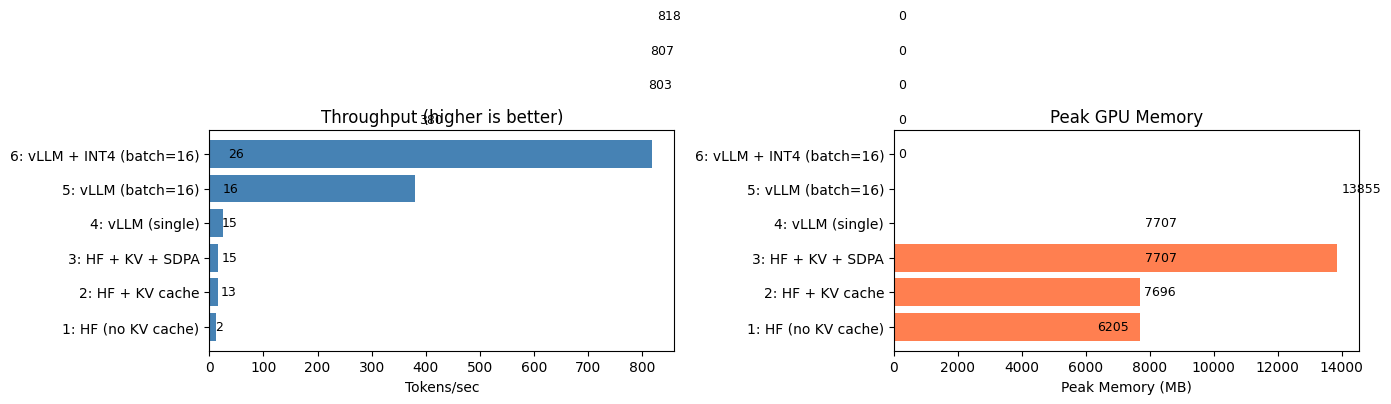

In [ ]:
# ---------- Visualization ----------
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

names = [r.config_name for r in ALL_RESULTS]
tps = [r.tokens_per_sec for r in ALL_RESULTS]
mem = [r.peak_memory_mb for r in ALL_RESULTS]

# Throughput
axes[0].barh(names, tps, color='steelblue')
axes[0].set_xlabel('Tokens/sec')
axes[0].set_title('Throughput (higher is better)')
for i, v in enumerate(tps):
    axes[0].text(v + max(tps)*0.01, i, f'{v:.0f}', va='center', fontsize=9)

# Memory
axes[1].barh(names, mem, color='coral')
axes[1].set_xlabel('Peak Memory (MB)')
axes[1].set_title('Peak GPU Memory')
for i, v in enumerate(mem):
    axes[1].text(v + max(mem)*0.01, i, f'{v:.0f}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

### Part 4 Annotations

For each transition above, write **one sentence** explaining the mechanism behind the performance change. Use concepts from the course: arithmetic intensity, memory bandwidth, KV cache, compute vs memory bound, batch amortization.

**Bad example** : *"Config 5 is faster because vLLM batches requests."* - This is valid, but doesn't explain  about the mechanism.

**Good example**: *"Config 5 improves aggregate throughput because batching amortizes the model weight reads across 16 requests in the MLP layers (weight data read once, used 16 times), increasing arithmetic intensity from ~1 to ~16 FLOPs/byte."*

**Config 1 → 2** (add KV cache)

YOUR ANSWER: *...*

**Config 2 → 3** (add SDPA / efficient attention)

YOUR ANSWER: *...*

**Config 3 → 4** (HF → vLLM, single request)

YOUR ANSWER: *...*

**Config 4 → 5** (single request → batch of 16)

YOUR ANSWER: *...*

**Config 5 → 6** (add INT4 quantization)

YOUR ANSWER: *...*

**Overall:** Which single optimization gave the largest speedup? Was it a compute optimization or a memory optimization? Is that consistent with what the roofline analysis in Part 1 predicted?

YOUR ANSWER: *...*

### Part 5 Optimization

Implement your own optimization that will push throughput beyond vLLM + INT4 quantization

Some optimizatios you can consider
1. Speculative Decoding
2. A better quantization
3. Graph fusion
4. Well tuned vLLM or SGLang
5. Your custom runtime


In [ ]:
# add your inference code and use above benchmarkign code

In [ ]:
# plot your optimized run times along with above and add your analysis following same structure as above

### Part 6 : Submission

**Add all you annotations and code in this notebook. NO EXTRA REPORT NEEDED**

Send this notebook to email id **llmcourse.iisc@gmail.com** and also share this notebook to the same email ID.

NOTE : email ID is different from the last assignment



